# Uber Ride Data Science Lifecycle Report
## Executive Summary
This notebook presents an end-to-end Uber ride analytics project: data loading, cleaning, exploratory analysis, statistical testing, feature engineering, supervised/unsupervised modeling, and business recommendations.

**Business Objective:** Improve pricing intelligence, demand planning, and operational efficiency using data-driven insights.

## 1) Problem Definition
We address these key questions:
1. What are the temporal and spatial demand patterns?
2. Which factors influence fare amounts most?
3. Can we reliably predict fare and ride categories?
4. Are there meaningful ride segments and behavioral patterns for operations?

In [1]:
# Core libraries
import warnings
warnings.filterwarnings('ignore')

import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project modules
from data_preprocessing import (
    load_data,
    show_basic_info,
    check_data_types_and_missing,
    clean_uber_data,
    save_cleaned_data,
)

# NOTE:
# The project file is named statistics.py, which conflicts with Python's stdlib module `statistics`.
# Load the local project module explicitly by file path.
_stats_candidates = [
    Path.cwd() / "statistics.py",
    Path.cwd() / "uber_ride_analysis" / "statistics.py",
]
_stats_path = next((p for p in _stats_candidates if p.exists()), None)
if _stats_path is None:
    raise FileNotFoundError("Could not locate project statistics.py module.")

_spec = importlib.util.spec_from_file_location("uber_project_statistics", str(_stats_path))
uber_stats = importlib.util.module_from_spec(_spec)
assert _spec.loader is not None
_spec.loader.exec_module(uber_stats)

numerical_statistical_summary = uber_stats.numerical_statistical_summary
ride_time_distribution = uber_stats.ride_time_distribution
identify_peak_periods = uber_stats.identify_peak_periods
fare_patterns = uber_stats.fare_patterns
central_tendency_variability = uber_stats.central_tendency_variability
categorical_frequency_tables = uber_stats.categorical_frequency_tables
ttest_weekday_vs_weekend_fares = uber_stats.ttest_weekday_vs_weekend_fares
anova_fare_by_hour = uber_stats.anova_fare_by_hour
chi_square_time_of_day_passenger = uber_stats.chi_square_time_of_day_passenger
z_test_mean_fare = uber_stats.z_test_mean_fare
correlation_coefficients = uber_stats.correlation_coefficients
linear_regression_fare_determinants = uber_stats.linear_regression_fare_determinants
pca_eigen_decomposition = uber_stats.pca_eigen_decomposition

from visualizations import (
    matplotlib_line_rides_over_time,
    matplotlib_bar_rides_by_hour_and_day,
    matplotlib_hist_fare_distribution,
    matplotlib_scatter_fare_vs_distance,
    matplotlib_pie_rides_by_base,
    matplotlib_3d_lat_lon_fare,
    matplotlib_heatmap_rides_hour_day,
    seaborn_box_fare_by_time_of_day,
    seaborn_violin_distance_by_passenger,
    seaborn_swarm_fare_by_day_of_week,
    seaborn_correlation_heatmap,
    seaborn_pairplot_numeric,
    seaborn_countplot_categorical,
)
from ml_models import (
    engineer_features,
    train_regression_models,
    train_classification_models,
    kmeans_clustering_analysis,
    plot_kmeans_elbow_silhouette,
    plot_kmeans_clusters_map,
    hierarchical_clustering_analysis,
    plot_hierarchical_dendrogram,
    decision_tree_regressor_analysis,
    plot_decision_tree_structure,
    association_rule_mining,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

# Robust dataset path resolution
_data_candidates = [
    Path.cwd() / "data" / "uber.csv",                 # when cwd is workspace root (c:/llm)
    Path.cwd() / "uber.csv",                           # dataset copied near notebook execution cwd
    Path.cwd().parent / "data" / "uber.csv",          # fallback for nested execution folders
]
_data_path_obj = next((p for p in _data_candidates if p.exists()), None)
if _data_path_obj is None:
    raise FileNotFoundError(
        "Could not find uber.csv. Expected one of: "
        + ", ".join(str(p) for p in _data_candidates)
    )

DATA_PATH = str(_data_path_obj)
CLEANED_OUTPUT_PATH = str(Path.cwd() / 'uber_rides_cleaned.csv')
print('Using DATA_PATH:', DATA_PATH)


def resolve_datetime_column(df: pd.DataFrame) -> str | None:
    """Find the most likely datetime column name in a dataset."""
    candidates = [
        'datetime', 'pickup_datetime', 'pickup_date', 'timestamp',
        'date_time', 'trip_datetime', 'request_datetime',
    ]
    cols_lower = {c.lower(): c for c in df.columns}

    # Exact preferred matches
    for cand in candidates:
        if cand in cols_lower:
            return cols_lower[cand]

    # Fallback heuristic: any column containing both date/time signals
    for c in df.columns:
        cl = c.lower()
        if ('date' in cl) or ('time' in cl):
            return c

    return None

Using DATA_PATH: c:\llm\data\uber.csv


## 2) Data Collection / Loading
Load raw Uber trip CSV data and inspect initial structure.

In [2]:
# Resolve path again in this cell so it works even if setup cells were not re-run
from pathlib import Path

if ('DATA_PATH' not in globals()) or (not Path(DATA_PATH).exists()):
    _reload_candidates = [
        Path.cwd() / 'data' / 'uber.csv',
        Path.cwd() / 'uber.csv',
        Path.cwd().parent / 'data' / 'uber.csv',
    ]
    _found = next((p for p in _reload_candidates if p.exists()), None)
    if _found is None:
        raise FileNotFoundError(
            'Could not find uber.csv. Checked: ' + ', '.join(str(p) for p in _reload_candidates)
        )
    DATA_PATH = str(_found)

print('Loading dataset from:', DATA_PATH)
df = load_data(DATA_PATH)

# Auto-detect datetime column and normalize it to `datetime` for downstream cells
_datetime_col_detected = resolve_datetime_column(df)
if _datetime_col_detected is None:
    raise ValueError(
        'No datetime-like column found. Available columns: '
        + ', '.join(df.columns.astype(str).tolist())
    )

if _datetime_col_detected != 'datetime':
    df = df.rename(columns={_datetime_col_detected: 'datetime'})

print(f"Using datetime column: '{_datetime_col_detected}' -> standardized as 'datetime'")
show_basic_info(df)
display(check_data_types_and_missing(df))

Loading dataset from: c:\llm\data\uber.csv
Using datetime column: 'pickup_datetime' -> standardized as 'datetime'

=== Dataset Shape ===
(200000, 9)

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   datetime           200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 13.7 MB
None

=== First 5 Rows ===
   Unnamed: 0                            key  fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003

,dtype,missing_values,missing_pct
dropoff_latitude,float64,1,0.0
dropoff_longitude,float64,1,0.0
Unnamed: 0,int64,0,0.0
key,str,0,0.0
fare_amount,float64,0,0.0
pickup_longitude,float64,0,0.0
datetime,str,0,0.0
pickup_latitude,float64,0,0.0
passenger_count,int64,0,0.0


## 3) Data Cleaning and Preprocessing
Cleaning includes missing value handling, duplicate removal, datetime parsing, feature extraction, outlier handling, and scaling.

In [3]:
df_clean = clean_uber_data(
    df,
    missing_drop_threshold=0.6,
    outlier_iqr_multiplier=1.5,
    scaling_method='standardize',
)
save_cleaned_data(df_clean, CLEANED_OUTPUT_PATH)
print('Raw shape:', df.shape)
print('Clean shape:', df_clean.shape)
display(df_clean.head())

Raw shape: (200000, 9)
Clean shape: (182153, 15)


,Unnamed: 0,key,fare_amount,datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,year,day_of_week,time_of_day
0,-0.216985,2015-05-07 19:52:06.0000003,-0.348298,2015-05-07 19:52:06+00:00,-0.127785,0.100971,-0.109189,0.115695,-0.494523,0.839392,-1.002583,-0.367337,1.776198,-0.025663,Evening
1,0.007688,2009-07-17 20:04:56.0000002,-0.300018,2009-07-17 20:04:56+00:00,-0.127305,0.099673,-0.108828,0.119685,-0.494523,0.992966,0.148899,0.213684,-1.457524,0.489110,Evening
2,1.078845,2009-08-24 21:45:00.00000061,0.955266,2009-08-24 21:45:00+00:00,-0.128245,0.101281,-0.106410,0.122972,-0.494523,1.146540,0.954936,0.504194,-1.457524,-1.569983,Evening
3,-0.113516,2009-06-26 08:22:21.0000001,-0.879380,2009-06-26 08:22:21+00:00,-0.125700,0.107697,-0.106617,0.127492,0.943712,-0.849923,1.185232,-0.076826,-1.457524,0.489110,Morning
4,-0.630981,2014-08-28 17:47:00.000000188,1.703609,2014-08-28 17:47:00+00:00,-0.121203,0.101705,-0.107201,0.121293,2.381948,0.532243,1.415528,0.504194,1.237245,-0.025663,Afternoon


## 4) Exploratory Data Analysis (EDA)
We summarize distributions, temporal demand, relationships, and categorical frequencies.

In [4]:
# Numerical profile
num_summary = numerical_statistical_summary(df_clean)
display(num_summary)

# Time distributions (robust to non-standard datetime column names)
_datetime_col_current = 'datetime' if 'datetime' in df.columns else resolve_datetime_column(df)
if _datetime_col_current is None:
    raise ValueError(
        'No datetime-like column found for time distribution. Available columns: '
        + ', '.join(df.columns.astype(str).tolist())
    )

_df_time = df if _datetime_col_current == 'datetime' else df.rename(columns={_datetime_col_current: 'datetime'})
time_dist = ride_time_distribution(_df_time, datetime_col='datetime')
display(time_dist['by_hour'].to_frame('rides'))
display(time_dist['by_day'].to_frame('rides'))
display(time_dist['by_month'].to_frame('rides'))

# Categorical frequencies
freq_tables = categorical_frequency_tables(df_clean)
for col, tbl in freq_tables.items():
    print(f'Frequency table: {col}')
    display(tbl.head(15))

,mean,median,mode,std,variance,min,q1_25%,q2_50%,q3_75%,max,iqr,cv
Unnamed: 0,1.092224e-17,0.002743,-1.730932,1.000003,1.000005,-1.730932,-0.867397,0.002743,0.864072,1.730891,1.731469,9.155652e+16
fare_amount,1.022010e-16,-0.227598,-0.589699,1.000003,1.000005,-2.158804,-0.782819,-0.227598,0.496605,3.200294,1.279424,9.784666e+15
pickup_longitude,-7.111942e-16,-0.126239,6.384430,1.000003,1.000005,-111.596829,-0.127129,-0.126239,-0.125079,11.437434,0.002049,1.406090e+15
pickup_latitude,2.652545e-17,0.102788,-5.119364,1.000003,1.000005,-14.603189,0.100633,0.102788,0.104577,205.601745,0.003944,3.769974e+16
dropoff_longitude,-1.438616e-16,-0.107784,5.454976,1.000003,1.000005,-246.939158,-0.108598,-0.107784,-0.106720,92.194297,0.001879,6.951146e+15
dropoff_latitude,-8.886026e-17,0.120109,-5.879699,1.000003,1.000005,-135.728243,0.117472,0.120109,0.122196,122.601455,0.004724,1.125365e+16
passenger_count,7.146269e-17,-0.494523,-0.494523,1.000003,1.000005,-0.494523,-0.494523,-0.494523,0.224595,148.362843,0.719118,1.399335e+16
hour,-1.195206e-16,0.071521,0.839392,1.000003,1.000005,-2.078515,-0.696349,0.071521,0.839392,1.453688,1.535740,8.366784e+15
day,6.541644e-17,0.033751,-0.887434,1.000003,1.000005,-1.693471,-0.887434,0.033751,0.839787,1.760972,1.727222,1.528672e+16
month,-9.549163e-17,-0.076826,-0.948357,1.000003,1.000005,-1.529378,-0.948357,-0.076826,0.794704,1.666235,1.743061,1.047215e+16


,rides
datetime,
0,7844
1,5908
2,4422
3,3256
4,2365
5,1967
6,4139
7,7231
8,9075


,rides
datetime,
Monday,25243
Tuesday,28127
Wednesday,29037
Thursday,30021
Friday,30880
Saturday,30251
Sunday,26441


,rides
datetime,
1,17668
2,16695
3,18763
4,18606
5,18859
6,17787
7,15095
8,14221
9,15266


Frequency table: key


,key,frequency,percentage
0,2015-05-07 19:52:06.0000003,1,0.0
1,2009-07-17 20:04:56.0000002,1,0.0
2,2009-08-24 21:45:00.00000061,1,0.0
3,2009-06-26 08:22:21.0000001,1,0.0
4,2014-08-28 17:47:00.000000188,1,0.0
5,2011-02-12 02:27:09.0000006,1,0.0
6,2012-12-11 13:52:00.00000029,1,0.0
7,2012-02-17 09:32:00.00000043,1,0.0
8,2012-03-29 19:06:00.000000273,1,0.0
9,2015-05-22 17:32:27.0000004,1,0.0


Frequency table: time_of_day


,time_of_day,frequency,percentage
0,Evening,63417,34.82
1,Afternoon,51717,28.39
2,Morning,44013,24.16
3,Night,23006,12.63


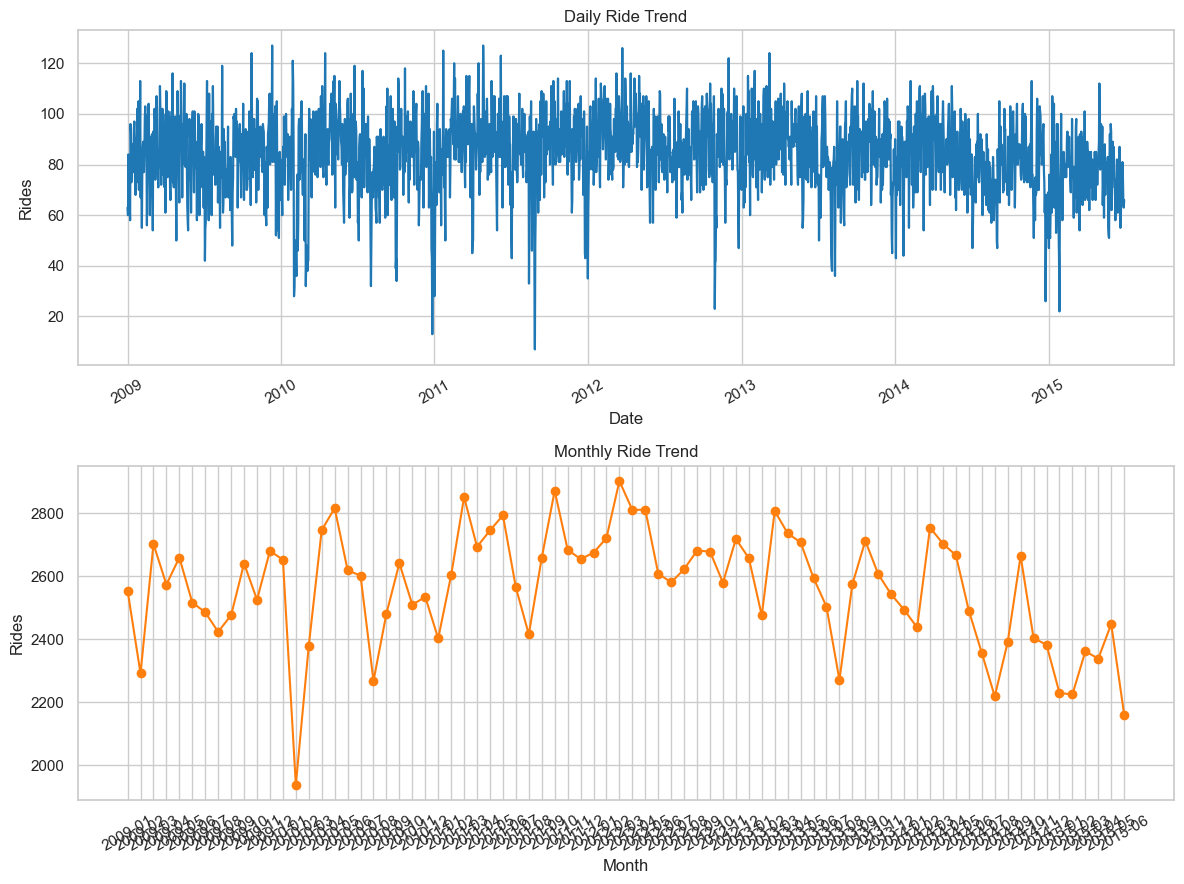

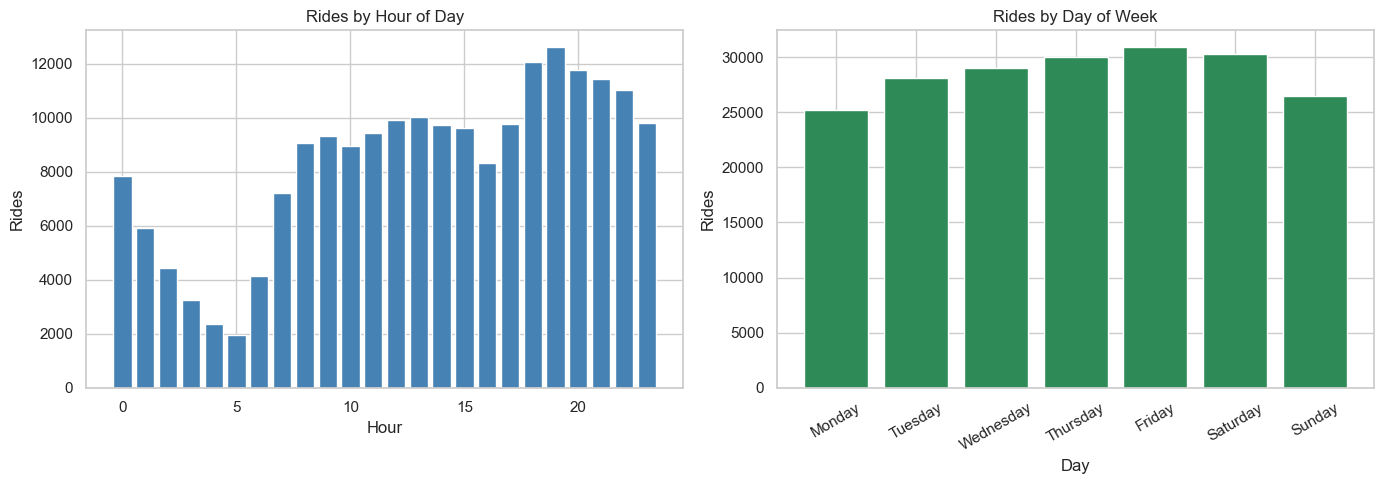

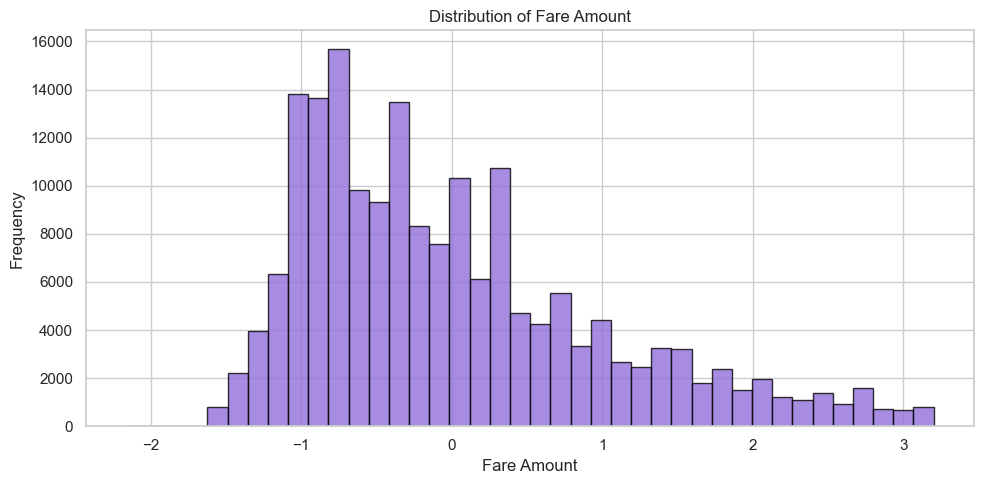

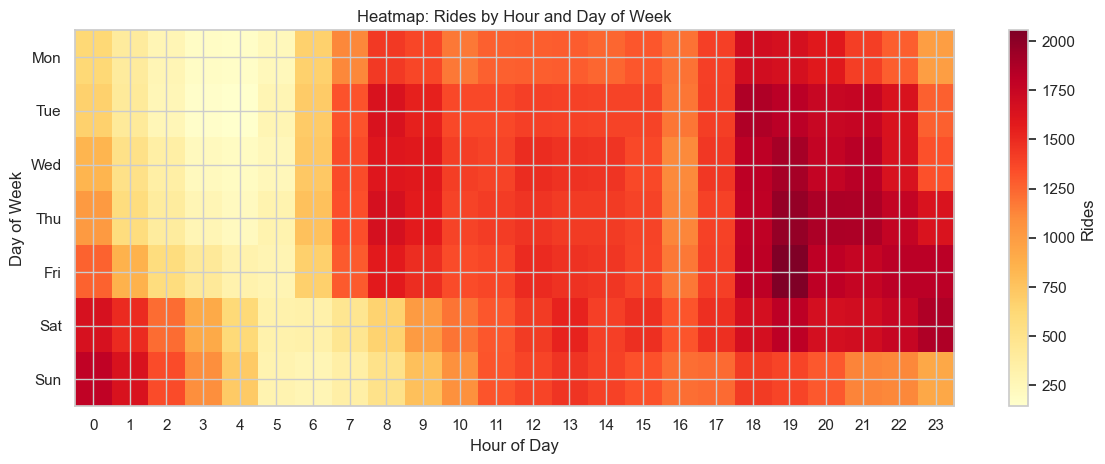

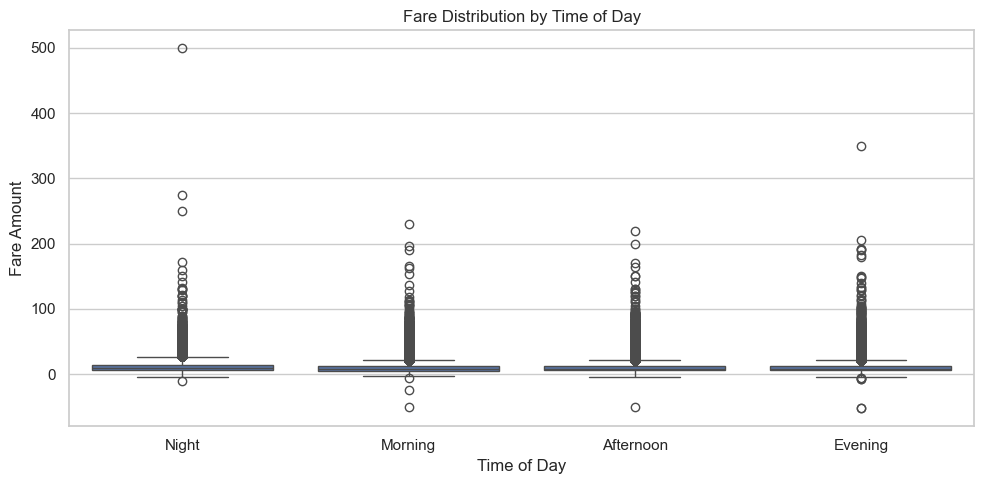

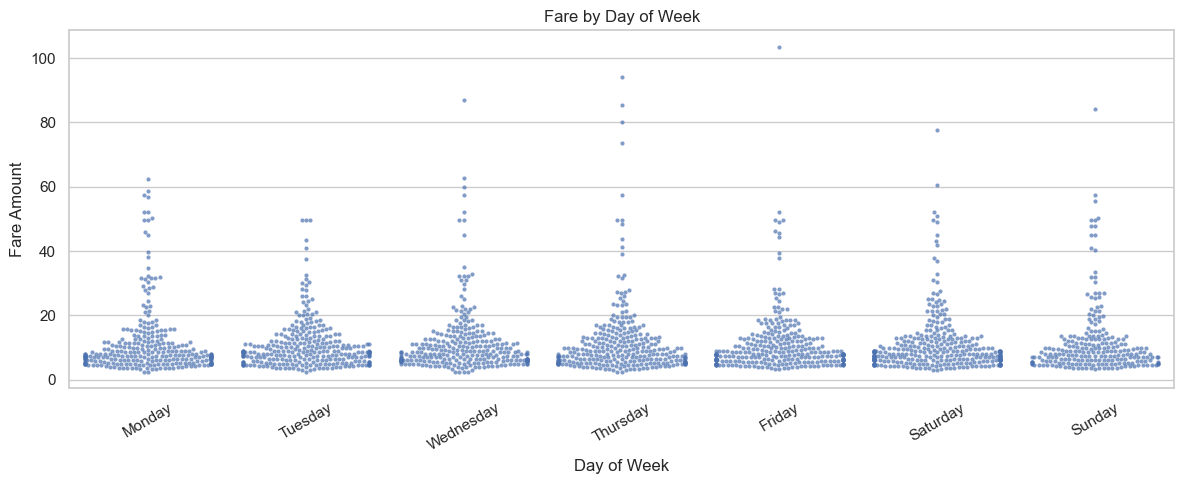

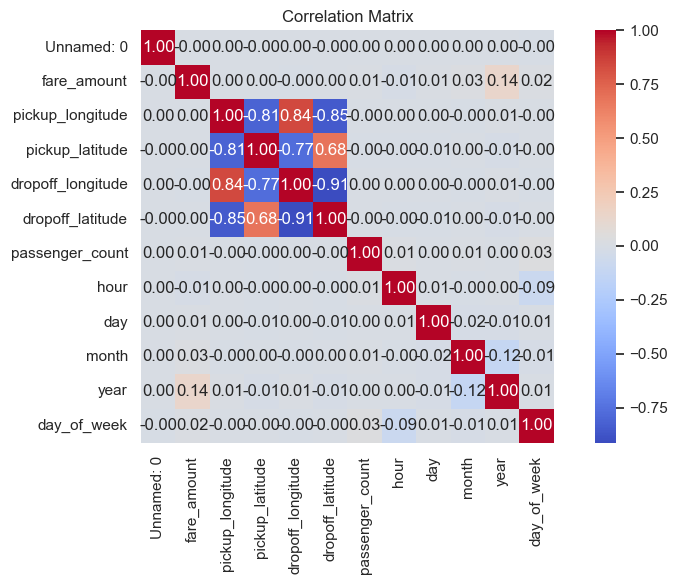

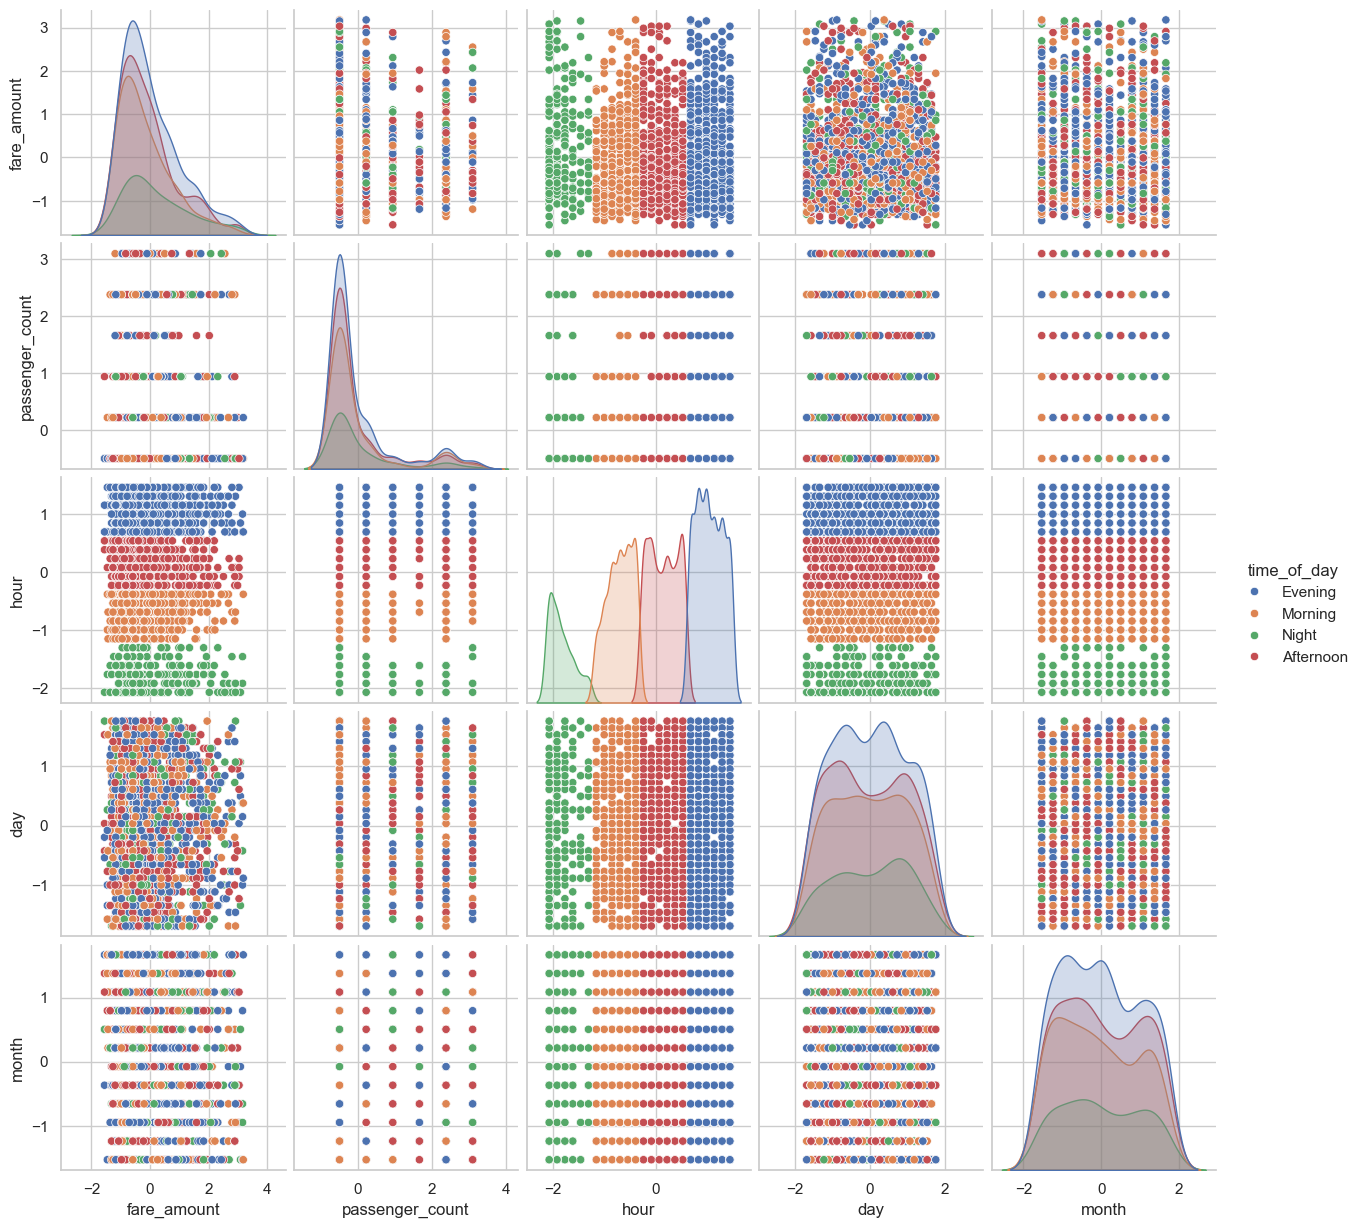

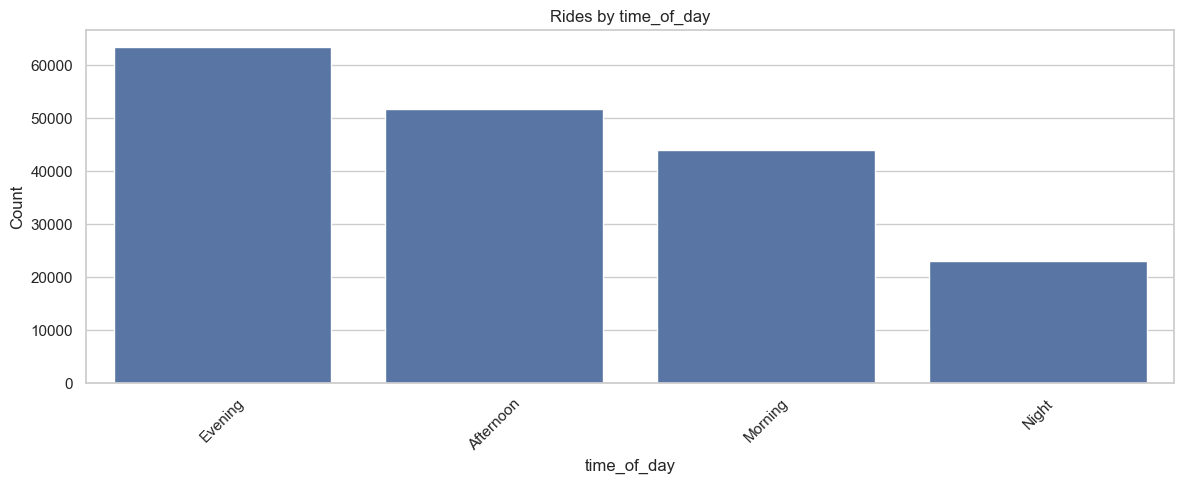

In [5]:
# Visual EDA (Matplotlib + Seaborn)
# Make visualization step robust to non-standard datetime column names
_datetime_col_viz = 'datetime' if 'datetime' in df.columns else resolve_datetime_column(df)
if _datetime_col_viz is None:
    raise ValueError(
        'No datetime-like column found for visual EDA. Available columns: '
        + ', '.join(df.columns.astype(str).tolist())
    )

_df_viz = df if _datetime_col_viz == 'datetime' else df.rename(columns={_datetime_col_viz: 'datetime'})

matplotlib_line_rides_over_time(_df_viz, datetime_col='datetime')
matplotlib_bar_rides_by_hour_and_day(_df_viz, datetime_col='datetime')
matplotlib_hist_fare_distribution(df_clean, fare_col='fare_amount')

if {'fare_amount', 'distance'}.issubset(df_clean.columns):
    matplotlib_scatter_fare_vs_distance(df_clean, fare_col='fare_amount', distance_col='distance')

if 'base' in df.columns:
    matplotlib_pie_rides_by_base(df, base_col='base', top_n=10)

if {'lat', 'lon', 'fare_amount'}.issubset(df_clean.columns):
    matplotlib_3d_lat_lon_fare(df_clean, lat_col='lat', lon_col='lon', fare_col='fare_amount', sample_size=3000)

matplotlib_heatmap_rides_hour_day(_df_viz, datetime_col='datetime')
seaborn_box_fare_by_time_of_day(_df_viz, fare_col='fare_amount')

if {'distance', 'passenger_count'}.issubset(df_clean.columns):
    seaborn_violin_distance_by_passenger(df_clean, distance_col='distance', passenger_col='passenger_count')

seaborn_swarm_fare_by_day_of_week(_df_viz, fare_col='fare_amount', datetime_col='datetime', sample_size=2000)
seaborn_correlation_heatmap(df_clean)

pair_cols = [c for c in ['fare_amount', 'distance', 'passenger_count', 'hour', 'day', 'month'] if c in df_clean.columns]
if len(pair_cols) >= 2:
    seaborn_pairplot_numeric(df_clean, cols=pair_cols, hue='time_of_day' if 'time_of_day' in df_clean.columns else None, sample_size=2000)

cat_cols = [c for c in ['base', 'time_of_day'] if c in df_clean.columns or c in df.columns]
if cat_cols:
    plot_df = df_clean.copy()
    if 'base' not in plot_df.columns and 'base' in df.columns:
        plot_df['base'] = df['base']
    seaborn_countplot_categorical(plot_df, columns=cat_cols, top_n=12)

## 5) Statistical Analysis
Hypothesis tests and inference to validate observed patterns.

In [6]:
# Statistical analysis (robust to non-standard datetime column names)
_datetime_col_stats = 'datetime' if 'datetime' in df.columns else resolve_datetime_column(df)
if _datetime_col_stats is None:
    raise ValueError(
        'No datetime-like column found for statistical analysis. Available columns: '
        + ', '.join(df.columns.astype(str).tolist())
    )

_df_stats = df if _datetime_col_stats == 'datetime' else df.rename(columns={_datetime_col_stats: 'datetime'})

# Peak demand
peak_info = identify_peak_periods(_df_stats, datetime_col='datetime')
print('Peak hour/day:', peak_info)

# Fare patterns
fare_pattern_tables = fare_patterns(_df_stats, fare_col='fare_amount', datetime_col='datetime', location_col='base')
for name, table in fare_pattern_tables.items():
    print(f'\n{name}')
    display(table.head(15))

# Central tendency and variability (with fallback for older in-memory module versions)
try:
    ctv = central_tendency_variability(df_clean)
except AttributeError:
    _num = df_clean.select_dtypes(include=['number'])
    _mad = (_num.sub(_num.mean())).abs().mean() if not _num.empty else pd.Series(dtype=float)
    ctv = pd.DataFrame(
        {
            'mean': _num.mean(),
            'median': _num.median(),
            'mode': _num.mode(dropna=True).iloc[0] if not _num.mode(dropna=True).empty else np.nan,
            'range': _num.max() - _num.min(),
            'variance': _num.var(),
            'std': _num.std(),
            'iqr': _num.quantile(0.75) - _num.quantile(0.25),
            'mad': _mad,
        }
    )
display(ctv)

# Statistical tests
ttest_res = ttest_weekday_vs_weekend_fares(_df_stats, fare_col='fare_amount', datetime_col='datetime')
anova_res = anova_fare_by_hour(_df_stats, fare_col='fare_amount', datetime_col='datetime')

# Use a robust input for chi-square (must have passenger_count and either time_of_day or datetime)
if 'passenger_count' not in _df_stats.columns and 'passenger_count' in df_clean.columns:
    _df_chi = df_clean.copy()
else:
    _df_chi = _df_stats.copy()

chi_res = chi_square_time_of_day_passenger(
    _df_chi,
    time_col='time_of_day',
    passenger_col='passenger_count',
    datetime_col='datetime',
)
ztest_res = z_test_mean_fare(df_clean, hypothesized_mean=15.0, fare_col='fare_amount')

print('T-test:', ttest_res)
print('ANOVA:', anova_res)
print('Chi-square summary:', {k: v for k, v in chi_res.items() if k not in ['contingency_table', 'expected_frequencies']})
print('Z-test:', ztest_res)
if 'contingency_table' in chi_res:
    display(chi_res['contingency_table'])

# Correlation coefficients
corrs = correlation_coefficients(df_clean)
print('Pearson correlation')
display(corrs['pearson'])
print('Spearman correlation')
display(corrs['spearman'])
print('Kendall correlation')
display(corrs['kendall'])

# PCA preparation
pca_features = [c for c in ['fare_amount', 'distance', 'passenger_count', 'hour', 'day', 'month', 'year', 'day_of_week', 'lat', 'lon'] if c in df_clean.columns]
pca_res = pca_eigen_decomposition(df_clean, feature_cols=pca_features, standardize=True)
print('Eigenvalues:', pca_res.get('eigenvalues', []))
print('Explained variance ratio:', pca_res.get('explained_variance_ratio', []))
if 'eigenvectors' in pca_res:
    display(pca_res['eigenvectors'])

Peak hour/day: {'peak_hour': 19, 'peak_hour_rides': 12605, 'peak_day': 'Friday', 'peak_day_rides': 30880}

fare_by_hour


,hour,rides,avg_fare,median,fare_std
0,0,7844,11.656280,8.9,9.878617
1,1,5908,11.663277,9.0,9.107317
2,2,4422,11.449889,8.9,9.110817
3,3,3256,11.725396,9.0,9.313651
4,4,2365,14.134753,10.1,15.365073
5,5,1967,16.003157,9.4,15.614662
6,6,4139,11.920382,7.7,11.667064
7,7,7231,11.122868,8.0,10.034444
8,8,9075,10.895563,8.1,9.693797
9,9,9339,10.948391,8.5,9.327754



fare_by_day


,day_of_week,rides,avg_fare,median,fare_std
0,Monday,25243,11.378528,8.1,10.042967
1,Tuesday,28127,11.075793,8.1,9.327409
2,Wednesday,29037,11.351323,8.5,9.808372
3,Thursday,30021,11.517768,8.5,9.909788
4,Friday,30880,11.439793,8.5,10.163108
5,Saturday,30251,11.032273,8.5,9.098261
6,Sunday,26441,11.756463,8.5,10.950351


,mean,median,mode,range,variance,std,iqr,mad
Unnamed: 0,1.092224e-17,0.002743,-1.730932,3.461824,1.000005,1.000003,1.731469,0.865815
fare_amount,1.022010e-16,-0.227598,-0.589699,5.359098,1.000005,1.000003,1.279424,0.794142
pickup_longitude,-7.111942e-16,-0.126239,6.384430,123.034263,1.000005,1.000003,0.002049,0.251626
pickup_latitude,2.652545e-17,0.102788,-5.119364,220.204934,1.000005,1.000003,0.003944,0.206560
dropoff_longitude,-1.438616e-16,-0.107784,5.454976,339.133455,1.000005,1.000003,0.001879,0.214243
dropoff_latitude,-8.886026e-17,0.120109,-5.879699,258.329698,1.000005,1.000003,0.004724,0.237432
passenger_count,7.146269e-17,-0.494523,-0.494523,148.857366,1.000005,1.000003,0.719118,0.688726
hour,-1.195206e-16,0.071521,0.839392,3.532203,1.000005,1.000003,1.535740,0.841335
day,6.541644e-17,0.033751,-0.887434,3.454444,1.000005,1.000003,1.727222,0.862948
month,-9.549163e-17,-0.076826,-0.948357,3.195613,1.000005,1.000003,1.743061,0.866341


...

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,year,day_of_week
Unnamed: 0,1.000000,0.000504,0.004083,0.003832,0.007960,0.004210,0.003060,0.001126,0.000622,0.001408,0.000086,-0.004742
fare_amount,0.000504,1.000000,-0.046357,-0.070541,0.022444,-0.073374,0.019479,0.005165,0.006212,0.027131,0.137601,0.016923
pickup_longitude,0.004083,-0.046357,1.000000,0.573118,0.457315,0.278537,-0.020368,-0.007788,-0.004210,-0.003883,-0.000399,-0.030989
pickup_latitude,0.003832,-0.070541,0.573118,1.000000,0.252603,0.563063,-0.015031,0.010448,-0.001686,0.000451,-0.005423,-0.052721
dropoff_longitude,0.007960,0.022444,0.457315,0.252603,1.000000,0.520103,-0.017274,-0.021841,-0.008395,-0.003356,0.001685,-0.023798
dropoff_latitude,0.004210,-0.073374,0.278537,0.563063,0.520103,1.000000,-0.009859,0.002417,-0.005229,-0.000298,-0.001331,-0.041268
passenger_count,0.003060,0.019479,-0.020368,-0.015031,-0.017274,-0.009859,1.000000,0.037301,0.001785,0.008812,-0.016591,0.058658
hour,0.001126,0.005165,-0.007788,0.010448,-0.021841,0.002417,0.037301,1.000000,0.006315,-0.001671,0.003156,-0.062821
day,0.000622,0.006212,-0.004210,-0.001686,-0.008395,-0.005229,0.001785,0.006315,1.000000,-0.016132,-0.010421,0.005504
month,0.001408,0.027131,-0.003883,0.000451,-0.003356,-0.000298,0.008812,-0.001671,-0.016132,1.000000,-0.107704,-0.010106


Kendall correlation


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,year,day_of_week
Unnamed: 0,1.000000,0.000335,0.002722,0.002552,0.005306,0.002803,0.002377,0.000767,0.000420,0.000974,0.000061,-0.003383
fare_amount,0.000335,1.000000,-0.031924,-0.048168,0.014546,-0.049974,0.015282,0.003776,0.004258,0.019043,0.099610,0.012223
pickup_longitude,0.002722,-0.031924,1.000000,0.433854,0.321633,0.195655,-0.015827,-0.006329,-0.002853,-0.002696,-0.000280,-0.022026
pickup_latitude,0.002552,-0.048168,0.433854,1.000000,0.178412,0.404424,-0.011672,0.006693,-0.001143,0.000316,-0.003868,-0.037542
dropoff_longitude,0.005306,0.014546,0.321633,0.178412,1.000000,0.399517,-0.013391,-0.014876,-0.005686,-0.002327,0.001203,-0.016982
dropoff_latitude,0.002803,-0.049974,0.195655,0.404424,0.399517,1.000000,-0.007653,0.002368,-0.003555,-0.000205,-0.000950,-0.029504
passenger_count,0.002377,0.015282,-0.015827,-0.011672,-0.013391,-0.007653,1.000000,0.029639,0.001405,0.007120,-0.013785,0.048702
hour,0.000767,0.003776,-0.006329,0.006693,-0.014876,0.002368,0.029639,1.000000,0.004379,-0.001185,0.002312,-0.045453
day,0.000420,0.004258,-0.002853,-0.001143,-0.005686,-0.003555,0.001405,0.004379,1.000000,-0.011356,-0.007571,0.004007
month,0.000974,0.019043,-0.002696,0.000316,-0.002327,-0.000205,0.007120,-0.001185,-0.011356,1.000000,-0.080057,-0.007494


Eigenvalues: [1.16975946 1.0913833  1.02987686 1.01065409 0.99375016 0.89881035
 0.80576577]
Explained variance ratio: [0.16710849 0.1559119  0.14712527 0.14437916 0.14196431 0.12840148
 0.1151094 ]


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
fare_amount,0.535956,0.047185,0.560414,0.105758,0.294401,-0.027785,-0.545740
passenger_count,0.049251,0.180166,0.355254,-0.677655,-0.527132,0.319084,-0.003179
hour,-0.109939,-0.650995,0.224377,-0.271071,-0.126969,-0.650923,-0.021727
day,0.021329,-0.004692,-0.187358,-0.642389,0.734215,0.057577,0.096800
month,-0.406741,0.222870,0.674616,0.153889,0.260165,-0.052690,0.485427
year,0.707903,-0.189684,0.013498,0.064005,-0.054040,0.036181,0.674081
day_of_week,0.176692,0.675163,-0.137819,-0.125208,-0.098295,-0.682870,0.047853


## 6) Feature Engineering
Create model-ready temporal and ratio features.

In [7]:
ml_df = engineer_features(df_clean)
print('Engineered dataset shape:', ml_df.shape)
display(ml_df.head())

Engineered dataset shape: (182153, 19)


,Unnamed: 0,key,fare_amount,datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,year,day_of_week,time_of_day,distance,is_weekend,distance_per_passenger,fare_per_distance
0,-0.216985,2015-05-07 19:52:06.0000003,-0.348298,2015-05-07 19:52:06+00:00,-0.127785,0.100971,-0.109189,0.115695,-0.494523,19,7,5,2015,3,Evening,2.637507,0.0,-5.333436,-0.132056
1,0.007688,2009-07-17 20:04:56.0000002,-0.300018,2009-07-17 20:04:56+00:00,-0.127305,0.099673,-0.108828,0.119685,-0.494523,20,17,7,2009,4,Evening,3.028713,0.0,-6.124515,-0.099058
2,1.078845,2009-08-24 21:45:00.00000061,0.955266,2009-08-24 21:45:00+00:00,-0.128245,0.101281,-0.106410,0.122972,-0.494523,21,24,8,2009,0,Evening,3.422318,0.0,-6.920444,0.279128
3,-0.113516,2009-06-26 08:22:21.0000001,-0.879380,2009-06-26 08:22:21+00:00,-0.125700,0.107697,-0.106617,0.127492,0.943712,8,26,6,2009,4,Morning,3.057323,0.0,3.239677,-0.287631
4,-0.630981,2014-08-28 17:47:00.000000188,1.703609,2014-08-28 17:47:00+00:00,-0.121203,0.101705,-0.107201,0.121293,2.381948,17,28,8,2014,3,Afternoon,2.677344,0.0,1.124015,0.636306


## 7) Model Building and Evaluation
### 7.1 Regression: Predict `fare_amount`
Models: Linear Regression and SVR with 80/20 split.

In [8]:
import time

reg_start = time.perf_counter()
reg_results = train_regression_models(
    ml_df,
    target_col='fare_amount',
    test_size=0.2,
    random_state=42,
    svr_max_train_rows=15000,  # keeps SVR runtime practical on large datasets
)
reg_elapsed = time.perf_counter() - reg_start

print('Regression features:', reg_results['features'])
print(f"Regression runtime: {reg_elapsed:.2f} seconds")
print('Training info:', reg_results.get('training_info', {}))
display(reg_results['comparison'])

Regression features: ['distance', 'passenger_count', 'hour', 'day', 'month', 'year', 'day_of_week', 'is_weekend', 'distance_per_passenger']
Regression runtime: 60.87 seconds
Training info: {'Linear Regression': {'fit_rows': 145722, 'full_train_rows': 145722, 'was_subsampled': False}, 'SVR': {'fit_rows': 15000, 'full_train_rows': 145722, 'was_subsampled': True}}


,model,r2,rmse,mae
0,Linear Regression,0.020495,0.982927,0.78014
1,SVR,-0.058512,1.021800,0.76818


### 7.2 Classification: Predict ride category (`short`/`medium`/`long`)
Models: Logistic Regression, SVM, Random Forest Classifier.

In [9]:
import importlib
import time
from pathlib import Path

import pandas as pd
import ml_models as _mlm

# Ensure latest ml_models.py changes are loaded in this running kernel
_mlm = importlib.reload(_mlm)

# Fast-mode controls for large datasets
MAX_CLASSIFICATION_ROWS = 120000     # cap rows used in classification section
SVM_MAX_TRAIN_ROWS = 10000           # cap only SVM training rows
RF_N_ESTIMATORS = 120                # fewer trees -> faster training

# Make this cell runnable even if previous cells were skipped
if 'ml_df' not in globals():
    if 'df_clean' in globals():
        ml_df = _mlm.engineer_features(df_clean)
        print('`ml_df` was missing; rebuilt from `df_clean`.')
    elif 'df' in globals():
        ml_df = _mlm.engineer_features(df)
        print('`ml_df` was missing; rebuilt from `df`.')
    else:
        _candidates = [
            Path.cwd() / 'data' / 'uber.csv',
            Path.cwd() / 'uber.csv',
            Path.cwd().parent / 'data' / 'uber.csv',
        ]
        _data_path = next((p for p in _candidates if p.exists()), None)
        if _data_path is None:
            raise NameError(
                "`ml_df` is not defined and no fallback dataset was found. "
                "Run notebook cells 3, 5, and 7 first, or place uber.csv in data/."
            )
        _raw_df = pd.read_csv(_data_path)
        ml_df = _mlm.engineer_features(_raw_df)
        print(f"`ml_df` was missing; rebuilt from fallback file: {_data_path}")

# Prefer explicit distance-like column if present; otherwise let ml_models derive distance from coordinates
_distance_candidates = ['distance', 'trip_distance', 'trip_miles', 'miles', 'trip_km', 'km', 'ride_distance']
_distance_col = next((c for c in _distance_candidates if c in ml_df.columns), 'distance')

# Optional dataset cap to keep the section responsive
if len(ml_df) > MAX_CLASSIFICATION_ROWS:
    ml_df_clf = ml_df.sample(n=MAX_CLASSIFICATION_ROWS, random_state=42)
    print(f"Using sampled classification dataset: {len(ml_df_clf):,} rows (from {len(ml_df):,})")
else:
    ml_df_clf = ml_df
    print(f"Using full classification dataset: {len(ml_df_clf):,} rows")

clf_start = time.perf_counter()
clf_results = _mlm.train_classification_models(
    ml_df_clf,
    distance_col=_distance_col,
    test_size=0.2,
    random_state=42,
    svm_max_train_rows=SVM_MAX_TRAIN_ROWS,
    rf_n_estimators=RF_N_ESTIMATORS,
)
clf_elapsed = time.perf_counter() - clf_start

print(f"Classification runtime: {clf_elapsed:.2f} seconds")
print('Training info:', clf_results.get('training_info', {}))
display(clf_results['comparison'])

print('Confusion matrices:')
for model_name, cm in clf_results['confusion_matrices'].items():
    print(f'\n{model_name}')
    display(cm)

print('Random Forest feature importance:')
display(clf_results['feature_importance'])

Using sampled classification dataset: 120,000 rows (from 182,153)
Classification runtime: 29.73 seconds
Training info: {'Logistic Regression': {'fit_rows': 96000, 'full_train_rows': 96000, 'was_subsampled': False}, 'SVM': {'fit_rows': 10000, 'full_train_rows': 96000, 'was_subsampled': True}, 'Random Forest Classifier': {'fit_rows': 96000, 'full_train_rows': 96000, 'was_subsampled': False}}


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Random Forest Classifier,0.991542,0.991542,0.991542,0.991540
1,SVM,0.360750,0.363668,0.360750,0.360303
2,Logistic Regression,0.343583,0.340751,0.343583,0.333691


Confusion matrices:

Logistic Regression


,pred_long,pred_medium,pred_short
true_long,3499,3002,1659
true_medium,3257,3254,1409
true_short,3230,3197,1493



SVM


,pred_long,pred_medium,pred_short
true_long,2686,2835,2639
true_medium,1973,3254,2693
true_short,2060,3142,2718



Random Forest Classifier


,pred_long,pred_medium,pred_short
true_long,8110,33,17
true_medium,54,7820,46
true_short,19,34,7867


Random Forest feature importance:


,feature,importance
7,distance_per_passenger,0.832685
0,passenger_count,0.078170
2,day,0.026095
1,hour,0.024180
3,month,0.017074
4,year,0.012665
5,day_of_week,0.008686
6,is_weekend,0.000445


### 7.3 Additional Modeling: Clustering + Tree-Based Regression

Using sampled clustering dataset: 50,000 rows (from 182,153)


,k,inertia,silhouette_score
0,2,124868.008031,0.875973
1,3,85680.676580,0.876401
2,4,48082.690695,0.635220
3,5,31959.945123,0.635234
4,6,24100.655301,0.575356


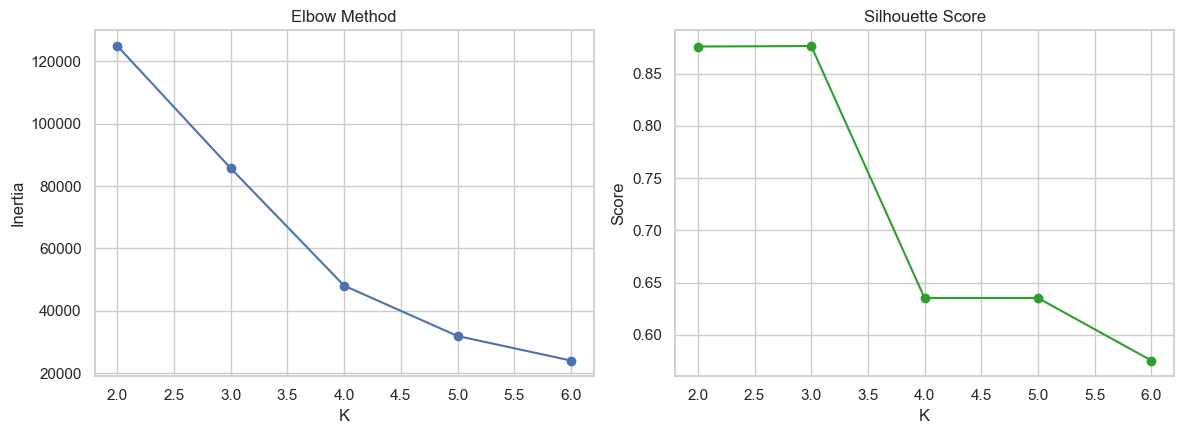

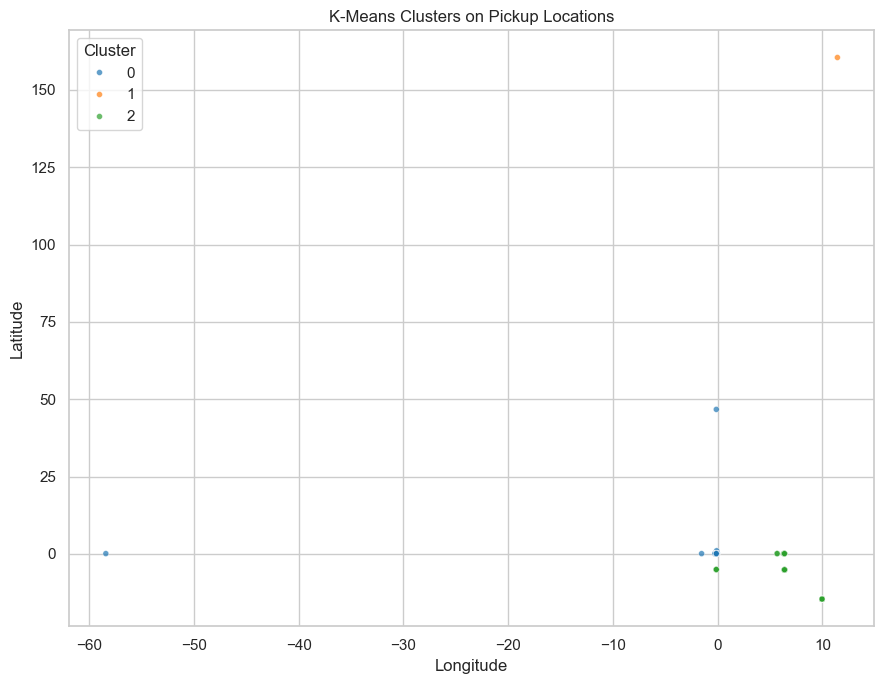

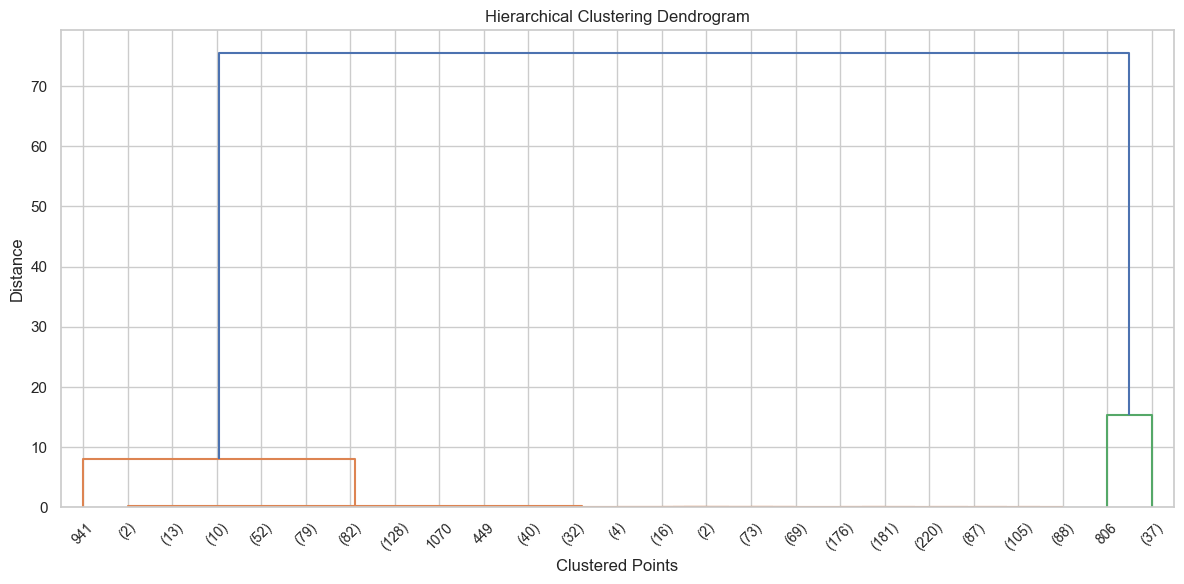

,pickup_latitude,pickup_longitude,cluster
87551,0.106520,-0.125666,1
9400,0.109556,-0.123824,1
185925,0.105184,-0.125245,1
38773,0.100987,-0.126788,1
182190,0.103626,-0.126853,1


Decision Tree metrics: {'r2': 0.5010472077570087, 'rmse': 0.7065329596970028, 'mae': 0.5305390174170539}


,feature,importance
0,distance,0.985917
3,pickup_longitude,0.009109
2,pickup_latitude,0.003678
4,hour,0.000934
5,day,0.000283
7,day_of_week,0.000080
1,passenger_count,0.000000
6,month,0.000000


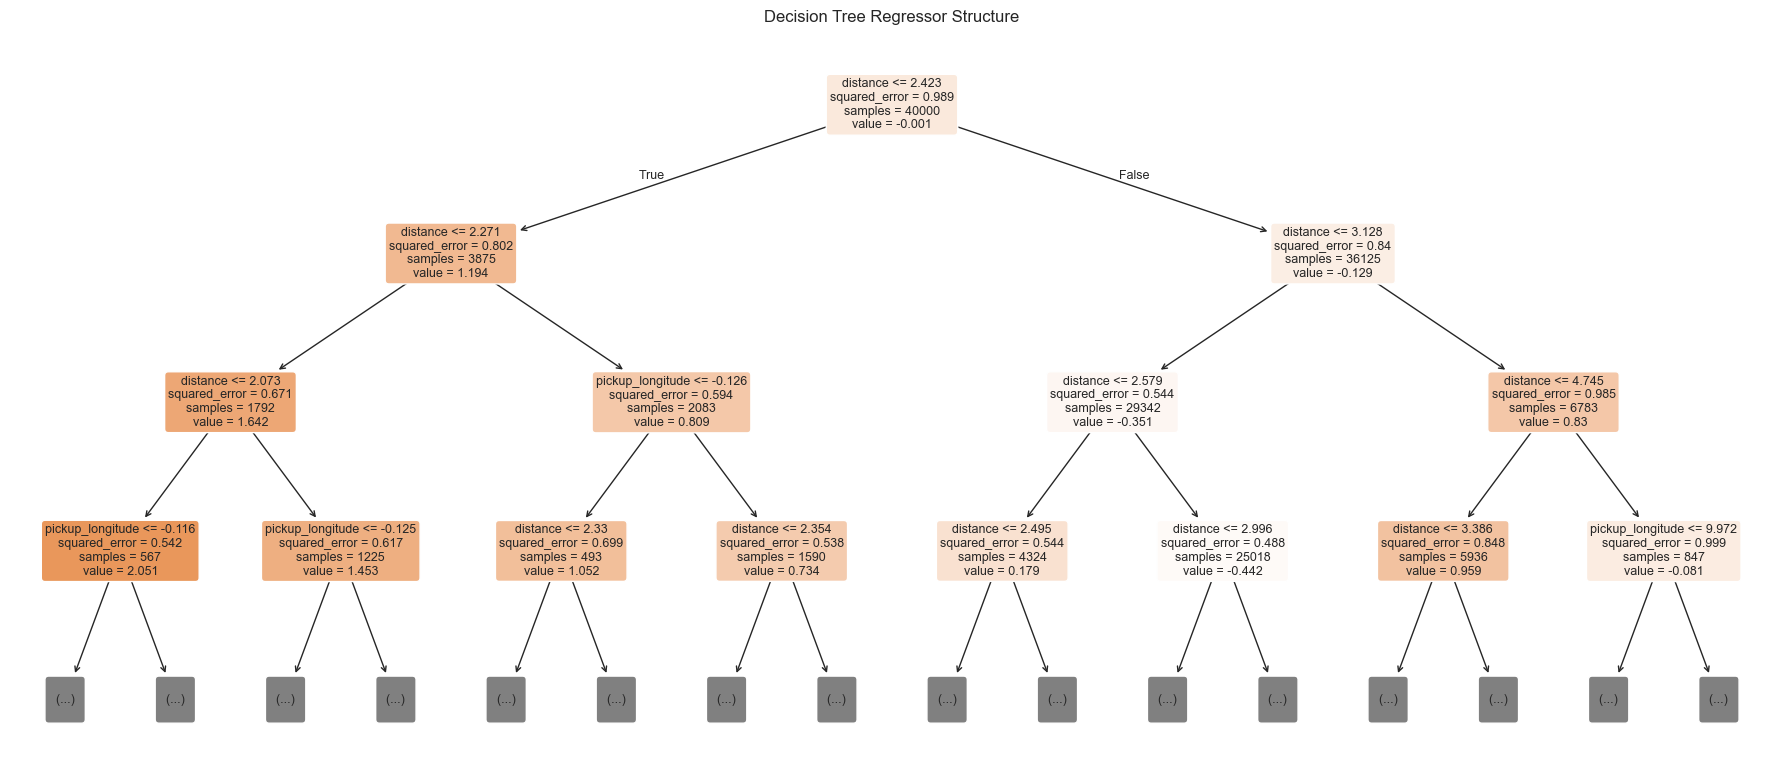

Association rules skipped (RUN_ASSOCIATION_RULES=False).


In [10]:
import importlib
from pathlib import Path

import pandas as pd
import ml_models as _mlm

# Ensure latest ml_models.py changes are loaded in this running kernel
_mlm = importlib.reload(_mlm)

# Fast-mode controls (this section can be expensive on large datasets)
MAX_CLUSTERING_ROWS = 50000
K_RANGE = (2, 6)
HIERARCHICAL_SAMPLE_SIZE = 1500
RUN_ASSOCIATION_RULES = False
ASSOCIATION_SAMPLE_ROWS = 20000

# Make this cell runnable even if previous cells were skipped
if 'ml_df' not in globals():
    if 'df_clean' in globals():
        ml_df = _mlm.engineer_features(df_clean)
        print('`ml_df` was missing; rebuilt from `df_clean`.')
    elif 'df' in globals():
        ml_df = _mlm.engineer_features(df)
        print('`ml_df` was missing; rebuilt from `df`.')
    else:
        _candidates = [
            Path.cwd() / 'data' / 'uber.csv',
            Path.cwd() / 'uber.csv',
            Path.cwd().parent / 'data' / 'uber.csv',
        ]
        _data_path = next((p for p in _candidates if p.exists()), None)
        if _data_path is None:
            raise NameError(
                "`ml_df` is not defined and no fallback dataset was found. "
                "Run notebook cells 3, 5, and 7 first, or place uber.csv in data/."
            )
        _raw_df = pd.read_csv(_data_path)
        ml_df = _mlm.engineer_features(_raw_df)
        print(f"`ml_df` was missing; rebuilt from fallback file: {_data_path}")

# Use a capped dataset for clustering workloads
if len(ml_df) > MAX_CLUSTERING_ROWS:
    ml_df_cluster = ml_df.sample(n=MAX_CLUSTERING_ROWS, random_state=42)
    print(f"Using sampled clustering dataset: {len(ml_df_cluster):,} rows (from {len(ml_df):,})")
else:
    ml_df_cluster = ml_df
    print(f"Using full clustering dataset: {len(ml_df_cluster):,} rows")

# Resolve best available location columns
_location_pairs = [
    ('lat', 'lon'),
    ('latitude', 'longitude'),
    ('pickup_latitude', 'pickup_longitude'),
    ('pickup_lat', 'pickup_lon'),
    ('start_lat', 'start_lon'),
]
location_cols = next((list(p) for p in _location_pairs if all(c in ml_df_cluster.columns for c in p)), None)

# K-Means clustering
kmeans_features = [c for c in ['fare_amount', 'distance'] if c in ml_df_cluster.columns]
if location_cols is not None:
    kmeans_features = location_cols + kmeans_features

if len(kmeans_features) < 2:
    raise ValueError(
        'Not enough features for K-Means. Need at least two among location/fare/distance columns. '
        f"Available columns: {', '.join(ml_df_cluster.columns.astype(str).tolist())}"
    )

kmeans_res = _mlm.kmeans_clustering_analysis(
    ml_df_cluster,
    feature_cols=kmeans_features,
    k_range=K_RANGE,
    random_state=42,
)
display(kmeans_res['evaluation'])
_mlm.plot_kmeans_elbow_silhouette(kmeans_res['evaluation'])

if location_cols is not None and {'cluster', *location_cols}.issubset(kmeans_res['clustered_data'].columns):
    _mlm.plot_kmeans_clusters_map(
        kmeans_res['clustered_data'],
        lat_col=location_cols[0],
        lon_col=location_cols[1],
        cluster_col='cluster',
    )
else:
    print('Location columns not available for cluster map; skipped map plot.')

# Hierarchical clustering
if location_cols is not None:
    hier_res = _mlm.hierarchical_clustering_analysis(
        ml_df_cluster,
        location_cols=location_cols,
        n_clusters=4,
        sample_size=HIERARCHICAL_SAMPLE_SIZE,
    )
    _mlm.plot_hierarchical_dendrogram(hier_res['linkage_matrix'], max_display_levels=25)
    display(hier_res['clustered_data'].head())
else:
    hier_res = {'clustered_data': pd.DataFrame(), 'linkage_matrix': None}
    print('No latitude/longitude-style columns found; hierarchical clustering skipped.')

# Decision tree regressor
dt_res = _mlm.decision_tree_regressor_analysis(
    ml_df_cluster,
    target_col='fare_amount',
    feature_cols=[c for c in ['distance', 'passenger_count', 'lat', 'lon', 'latitude', 'longitude', 'pickup_latitude', 'pickup_longitude', 'hour', 'day', 'month', 'day_of_week'] if c in ml_df_cluster.columns],
    test_size=0.2,
    random_state=42,
    max_depth=5,
)
print('Decision Tree metrics:', dt_res['metrics'])
display(dt_res['feature_importance'])
_mlm.plot_decision_tree_structure(dt_res['model'], feature_names=dt_res['feature_cols'], max_depth=3)

# Association rules (Apriori) - optional (often slow on large data)
if RUN_ASSOCIATION_RULES:
    _assoc_df = ml_df_cluster.sample(n=min(ASSOCIATION_SAMPLE_ROWS, len(ml_df_cluster)), random_state=42)
    try:
        ar_res = _mlm.association_rule_mining(_assoc_df, min_support=0.05, min_threshold=1.0)
        if 'message' in ar_res:
            print(ar_res['message'])
        display(ar_res['frequent_itemsets'].head(20))
        display(ar_res['rules'].head(20))
    except ImportError as e:
        print(str(e))
        print('Install dependencies and rerun this section.')
else:
    print('Association rules skipped (RUN_ASSOCIATION_RULES=False).')

## 8) Key Insights and Findings
This section auto-summarizes major outcomes for presentation use.

In [11]:
# Build a concise, presentation-ready findings table
insights = []

if 'peak_info' in globals():
    insights.append({'area': 'Demand Timing', 'finding': f"Peak hour: {peak_info.get('peak_hour')} | Peak day: {peak_info.get('peak_day')}"})

if 'reg_results' in globals() and not reg_results['comparison'].empty:
    best_reg = reg_results['comparison'].iloc[0]
    insights.append({'area': 'Fare Prediction', 'finding': f"Best regression model: {best_reg['model']} (R²={best_reg['r2']:.3f}, RMSE={best_reg['rmse']:.3f})"})

if 'clf_results' in globals() and not clf_results['comparison'].empty:
    best_clf = clf_results['comparison'].iloc[0]
    insights.append({'area': 'Ride Category Classification', 'finding': f"Best classifier: {best_clf['model']} (F1={best_clf['f1_weighted']:.3f}, Accuracy={best_clf['accuracy']:.3f})"})

if 'kmeans_res' in globals():
    insights.append({'area': 'Ride Segmentation', 'finding': f"Optimal K from silhouette: {kmeans_res['best_k']}"})

if 'ttest_res' in globals() and ttest_res.get('p_value') is not None:
    sig = 'significant' if ttest_res['p_value'] < 0.05 else 'not significant'
    insights.append({'area': 'Weekday vs Weekend Fares', 'finding': f"Difference is {sig} (p={ttest_res['p_value']:.4f})"})

insights_df = pd.DataFrame(insights)
display(insights_df)

,area,finding
0,Demand Timing,Peak hour: 19 | Peak day: Friday
1,Fare Prediction,Best regression model: Linear Regression (R²=0...
2,Ride Category Classification,Best classifier: Random Forest Classifier (F1=...
3,Ride Segmentation,Optimal K from silhouette: 3
4,Weekday vs Weekend Fares,Difference is not significant (p=0.7761)


## 9) Business Recommendations
1. **Dynamic pricing by peak demand**: Apply stronger surge controls during identified peak hour/day windows.
2. **Geo-targeted supply allocation**: Use clustering outputs to stage drivers in high-demand pickup zones.
3. **Distance-aware fare strategy**: Given fare-distance signal, monitor thresholds for short-trip profitability and long-trip retention.
4. **Model-driven operations dashboard**: Track production metrics (forecast error, cluster drift, category classification quality).
5. **Experimentation roadmap**: A/B test recommendation strategies for dispatch, incentive placement, and pricing interventions.

## 10) Final Conclusion
This notebook demonstrates a full data science lifecycle with documented methodology, statistical validation, predictive modeling, segmentation, and business translation.

For productionization, next steps include model monitoring, retraining schedules, and deployment to batch/stream decision services.